In [120]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [121]:
data = 'https://raw.githubusercontent.com/alexeygrigorev/datasets/master/course_lead_scoring.csv'

In [122]:
df = pd.read_csv(data)
df.head()

,lead_source,industry,number_of_courses_viewed,annual_income,employment_status,location,interaction_count,lead_score,converted
0,paid_ads,NaN,1,79450.0,unemployed,south_america,4,0.94,1
1,social_media,retail,1,46992.0,employed,south_america,1,0.80,0
2,events,healthcare,5,78796.0,unemployed,australia,3,0.69,1
3,paid_ads,retail,2,83843.0,NaN,australia,1,0.87,0
4,referral,education,3,85012.0,self_employed,europe,3,0.62,1


In [123]:
df.dtypes

lead_source                     str
industry                        str
number_of_courses_viewed      int64
annual_income               float64
employment_status               str
location                        str
interaction_count             int64
lead_score                  float64
converted                     int64
dtype: object

In [124]:
df.columns

Index(['lead_source', 'industry', 'number_of_courses_viewed', 'annual_income',
       'employment_status', 'location', 'interaction_count', 'lead_score',
       'converted'],
      dtype='str')

In [125]:
categorical = ['lead_source', 'industry','employment_status', 'location']
numerical = ['number_of_courses_viewed', 'annual_income','interaction_count', 'lead_score']

In [126]:
df.isnull().sum()

lead_source                 128
industry                    134
number_of_courses_viewed      0
annual_income               181
employment_status           100
location                     63
interaction_count             0
lead_score                    0
converted                     0
dtype: int64

In [127]:
df.shape

(1462, 9)

In [128]:
df[categorical] = df[categorical].fillna('na')
df[numerical] = df[numerical].fillna(0.0)


In [129]:
from sklearn.model_selection import train_test_split

In [ ]:
df_train_full, df_test = train_test_split(df,test_size=0.2,random_state=1)
df_train , df_val = train_test_split(df_train_full, test_size=0.25, random_state=1)

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

y_train = df_train.converted.values
y_test = df_test.converted.values
y_val = df_val.converted.values

del df_train['converted']
del df_val['converted']
del df_test['converted']
df_train.head()

,lead_source,industry,number_of_courses_viewed,annual_income,employment_status,location,interaction_count,lead_score
0,events,manufacturing,2,95543.0,unemployed,europe,3,0.78
1,referral,na,1,54924.0,student,south_america,6,0.39
2,organic_search,healthcare,2,77352.0,unemployed,europe,2,0.22
3,paid_ads,other,2,34600.0,employed,south_america,2,0.31
4,paid_ads,education,0,43615.0,unemployed,south_america,2,0.01


# Question 1: ROC AUC feature importance
ROC AUC could also be used to evaluate feature importance of numerical variables.

Let's do that

For each numerical variable, use it as score (aka prediction) and compute the AUC with the y variable as ground truth.
Use the training dataset for that
if your AUC is < 0.5, invert this variable by putting "-" in front

(e.g. -df_train['balance'])

AUC can go below 0.5 if the variable is negatively correlated with the target variable. You can change the direction of the correlation by negating this variable - then negative correlation becomes positive.

Which numerical variable (among the following 4) has the highest AUC?

lead_score
number_of_courses_viewed
interaction_count
annual_income

In [131]:
from sklearn.metrics import roc_auc_score, roc_curve

In [132]:
for num in numerical:
    auc = roc_auc_score(y_train,df_train[num])

    if auc < 0.5:
        auc = roc_auc_score(y_train, -df_train[c])
    print(f"for {num} auc = {auc}")


for number_of_courses_viewed auc = 0.7635680590007088
for annual_income auc = 0.5519578313253012
for interaction_count auc = 0.738270176293409
for lead_score auc = 0.6144993577250176


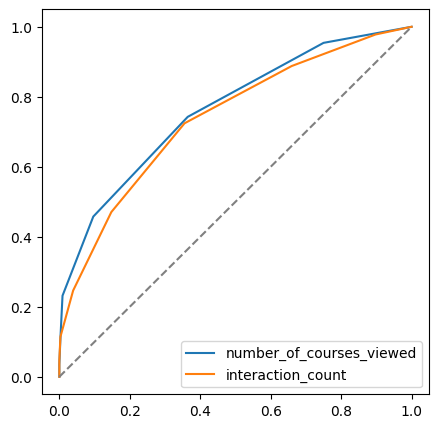

In [133]:
plt.figure(figsize=(5, 5))

fpr, tpr, _ = roc_curve(y_train, df_train.number_of_courses_viewed)
plt.plot(fpr, tpr, label='number_of_courses_viewed')

fpr, tpr, _ = roc_curve(y_train, df_train.interaction_count)
plt.plot(fpr, tpr, label='interaction_count')

plt.plot([0, 1], [0, 1], color='grey', linestyle='--')

plt.legend()
plt.show()

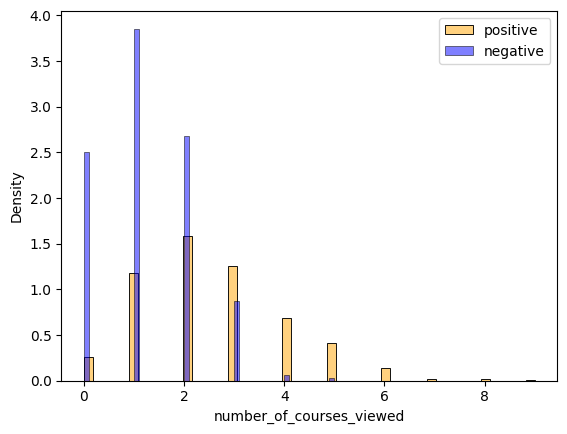

In [134]:
sns.histplot(df_train.number_of_courses_viewed[y_train == 1],
             stat='density', bins=50,
             color='orange', alpha=0.5,
             label='positive')
sns.histplot(df_train.number_of_courses_viewed[y_train == 0],
             stat='density', bins=50,
             color='blue', alpha=0.5,
             label='negative')

plt.legend()
plt.show()

# Question 2: Training the model
Apply one-hot-encoding using DictVectorizer and train the logistic regression with these parameters:

LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)
What's the AUC of this model on the validation dataset? (round to 3 digits)

0.32
0.52
0.72
0.92

In [135]:
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression

In [136]:
dv = DictVectorizer(sparse=False)
train_dict = df_train.to_dict(orient='records')
val_dict = df_val.to_dict(orient='records')
X_train = dv.fit_transform(train_dict)
X_val = dv.fit_transform(val_dict)


In [139]:
model = LogisticRegression(C=1.0, max_iter=1000)
model.fit(X_train,y_train)

y_pred = model.predict_proba(X_val)[:, 1]
y_pred


/workspaces/machine-learning-zoomcamp/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


array([0.025105  , 0.64456163, 0.90193973, 0.45781328, 0.94706933,
       0.85314084, 0.99744387, 0.18459165, 0.35719371, 0.99877434,
       0.96443901, 0.62360921, 0.99956949, 0.13726733, 0.95280129,
       0.99361996, 0.49553389, 0.01552119, 0.709269  , 0.97546903,
       0.93216151, 0.20356783, 0.99699496, 0.42168784, 0.99952154,
       0.29963251, 0.0492058 , 0.95949907, 0.70549408, 0.88484365,
       0.53728029, 0.7439399 , 0.07348657, 0.9984904 , 0.13310449,
       0.93818144, 0.92309822, 0.95394613, 0.01831154, 0.31013122,
       0.9840977 , 0.10364771, 0.39418746, 0.64637181, 0.8702632 ,
       0.0729589 , 0.31143045, 0.29579799, 0.80893838, 0.98259612,
       0.9652512 , 0.11069935, 0.99871945, 0.92388059, 0.94777797,
       0.72667557, 0.90422043, 0.24747782, 0.24070581, 0.86165879,
       0.00253737, 0.46381827, 0.05456266, 0.30925832, 0.29958706,
       0.17720065, 0.93039421, 0.00519676, 0.28648368, 0.84937935,
       0.99519069, 0.64471682, 0.36096192, 0.98621773, 0.62066

In [140]:
roc_auc_score(y_val, y_pred)

0.9204774230658613

# Question 3: Precision and Recall
Now let's compute precision and recall for our model.

Evaluate the model on all thresholds from 0.0 to 1.0 with step 0.01
For each threshold, compute precision and recall
Plot them
At which threshold precision and recall curves intersect?

0.145
0.345
0.545
0.745

In [146]:
scores = []
thresholds =np.linspace(0, 1 , 101)
for t in thresholds:
    actual_positive = (y_val == 1)
    actual_negative = (y_val == 0)
    
    pred_positive = (y_pred >= t)
    pred_negative = (y_pred < t)

    tp = (actual_positive & pred_positive).sum()
    tn = (actual_negative & pred_negative).sum()
    fp = (actual_negative & pred_positive).sum()
    fn = (actual_positive & pred_negative).sum()
    scores.append((t, tp, tn, fp, fn))

columns = ['threshold', 'tp', 'tn', 'fp', 'fn']
df_scores = pd.DataFrame(scores,columns=columns)
    



In [149]:
df_scores[::10]

,threshold,tp,tn,fp,fn
0,0.0,171,0,122,0
10,0.1,169,28,94,2
20,0.2,166,51,71,5
30,0.3,163,74,48,8
40,0.4,158,90,32,13
50,0.5,152,97,25,19
60,0.6,144,107,15,27
70,0.7,136,112,10,35
80,0.8,125,115,7,46
90,0.9,98,116,6,73


In [151]:
df_scores['precision'] = df_scores.tp / (df_scores.tp + df_scores.fp)
df_scores['recall'] = df_scores.tp / (df_scores.tp + df_scores.fn)

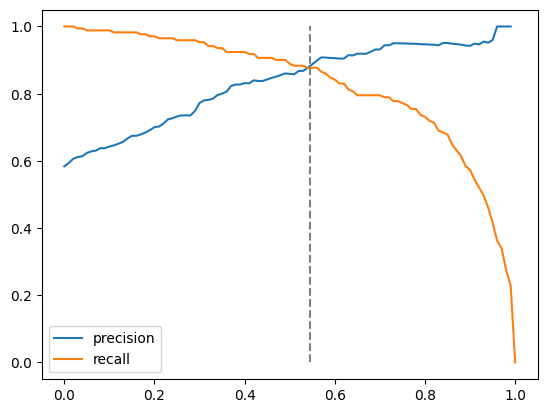

In [154]:
plt.plot(df_scores.threshold, df_scores.precision, label='precision')
plt.plot(df_scores.threshold, df_scores.recall, label='recall')

plt.vlines(0.545, 0, 1, color='grey', linestyle='--', alpha=1)

plt.legend()
plt.show()

# Question 4: F1 score
Precision and recall are conflicting - when one grows, the other goes down. That's why they are often combined into the F1 score - a metrics that takes into account both

This is the formula for computing F1:

F
1
=
2
⋅
P
⋅
R
P
+
R

Where 
P
 is precision and 
R
 is recall.

Let's compute F1 for all thresholds from 0.0 to 1.0 with increment 0.01

At which threshold F1 is maximal?

0.14
0.34
0.54
0.74

In [155]:
df_scores['f1'] = 2 * df_scores.precision * df_scores.recall / (df_scores.precision + df_scores.recall)

In [156]:
df_scores.loc[df_scores.f1.argmax()]

threshold      0.560000
tp           150.000000
tn           105.000000
fp            17.000000
fn            21.000000
p              0.898204
r              0.877193
precision      0.898204
recall         0.877193
f1             0.887574
Name: 56, dtype: float64

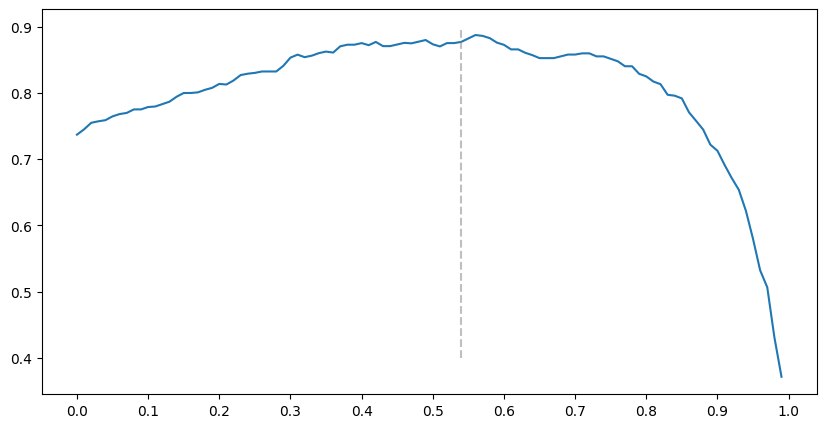

In [157]:
plt.figure(figsize=(10, 5))

plt.plot(df_scores.threshold, df_scores.f1)
plt.vlines(0.54, 0.4, 0.9, color='grey', linestyle='--', alpha=0.5)

plt.xticks(np.linspace(0, 1, 11))
plt.show()